<a href="https://colab.research.google.com/github/Luckaz7/Projeto_censo_escolar_alfenas_mg/blob/main/Projeto_censo_escolar_alfenas_mg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projeto de **análise de dados**, aplicando tecnicas de **engenharia de dados(ELT)** e **cloud computing(Google Cloud Storage)**, com o objetivo de análisar a queda no número de matriculas escolares na cidade de Alfenas/MG no decorrer dos anos de 2008 até 2024.

Fonte dos dados: https://cidades.ibge.gov.br/brasil/mg/alfenas/pesquisa/13/78117

# **Início do Projeto:**

**Importando os modulos necessários para a conexão do Drive e GCS:**

In [1]:
from google.colab import drive
from google.colab import auth
from google.cloud import storage

**Montando o acesso ao Google Drive:**

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


**Importando as bibliotecas necessárias para a manipulação dos dados:**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata
from io import BytesIO

**Criando uma função padrão de extração(E) de dados armazenados em arquivos .csv:**

In [4]:
def extracao_dados(dados: str) -> pd.DataFrame:
  try:
    data_frame = pd.read_csv(dados, sep=';')
    return data_frame
  except Exception as e:
    print(f'Erro ao extrair os dados: {e}')
    return None

**Criando uma função padrão para carga(L) dos dados no bucket do GCS:**

In [5]:
def carga_dados(dados: pd.DataFrame, destino: str, bucket: str) -> str:
  try:
    buffer = BytesIO()
    dados.to_parquet(buffer, index=False)
    buffer.seek(0)
    bucket = storage_cliente.bucket(bucket)
    blob = bucket.blob(destino)
    blob.upload_from_file(buffer, content_type='application/octet-stream')
    return f'Dados enviados com sucesso.'
  except Exception as e:
    print(f'Ocorreu um erro ao realizar o upload dos dados: {e}')
    return dados

**Criando uma função para padronização dos nomes das colunas já pensando na etapa de transformação(T):**

In [6]:
def padronizacao_nome_colunas(dados: pd.DataFrame) -> pd.DataFrame:
  try:
    df_bruto = dados.copy()
    df_bruto.columns = df_bruto.columns.str.replace(r'([a-z0-9])([A-Z])', r'\1_\2', regex=True).str.lower()
    return df_bruto
  except Exception as e:
    print(f'Erro na padronização: {e}')
    return dados

**Configurações iniciais e autenticação de usuário no GCS:**

In [13]:
id_projeto = userdata.get('id_projeto').strip("'")
nome_bucket = userdata.get('nome_bucket').strip("'")
auth.authenticate_user(project_id=id_projeto)
storage_cliente = storage.Client(project=id_projeto)

# **Extração dos dados brutos e armazendo-os na camada bronze no bucket do GCS:**

In [14]:
df = extracao_dados('/content/drive/MyDrive/Livros Programação /Engenharia de Dados/Python/Censo escolar - sinopse - Alfenas.csv')
carga_dados(df, 'dados_matriculas_alfenas/bronze/matriculas.parquet', nome_bucket)

'Dados enviados com sucesso.'

# **Inicio da Etapa de Transformação:**

In [15]:
df = padronizacao_nome_colunas(df)
df.sample(5)

,nível,indicador,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,unidade
109,1.3,Escolas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,1.2.1.2.4,Privado,28.0,34.0,36.0,34.0,37.0,31.0,36.0,54.0,41.0,38.0,35.0,35.0,37.0,35.0,39.0,48.0,45.0,docentes
73,1.1.3.3.3,Federal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,matrículas
88,1.2.1.1.1,Municipal,40.0,67.0,63.0,55.0,81.0,82.0,88.0,112.0,115.0,114.0,124.0,117.0,131.0,124.0,125.0,128.0,127.0,docentes
79,1.1.3.4.4,Privado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,matrículas


**Filtragem de dados, padronização dos nomes das colunas e tratamento de NaNs:**

In [16]:
filtro = (df['indicador'].isin(['1º ano','2º ano','3º ano','4º ano','5º ano','6º ano','7ºano','8º ano','9º ano'])) & (df['unidade'] == 'matrículas')
df_matriculas_anos = df[filtro]
df_matriculas_anos = df_matriculas_anos.reset_index(drop=True)
df_matriculas_anos = df_matriculas_anos.drop('nível', axis=1)

df_matriculas_anos = df_matriculas_anos[['unidade','indicador','2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024']]
df_matriculas_anos = df_matriculas_anos.rename(columns={'unidade':'descricao','indicador':'ano_escolar'})
df_matriculas_anos = df_matriculas_anos.fillna(0)

df_matriculas_anos.head(10)

,descricao,ano_escolar,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,matrículas,1º ano,1150.0,985.0,972.0,895.0,849.0,955.0,1219.0,922.0,943.0,895.0,984.0,1004.0,986.0,0.0,894.0,947.0,973.0
1,matrículas,2º ano,1223.0,1169.0,1021.0,1023.0,903.0,867.0,1068.0,1220.0,933.0,990.0,876.0,962.0,1015.0,0.0,911.0,907.0,933.0
2,matrículas,3º ano,1322.0,1317.0,1223.0,994.0,1029.0,937.0,977.0,989.0,1227.0,948.0,1011.0,931.0,990.0,0.0,956.0,937.0,909.0
3,matrículas,4º ano,1151.0,1218.0,1275.0,1209.0,997.0,1021.0,1041.0,893.0,970.0,1237.0,935.0,999.0,908.0,0.0,1020.0,983.0,946.0
4,matrículas,5º ano,1060.0,1332.0,1311.0,1353.0,1326.0,1094.0,1117.0,1000.0,918.0,980.0,1245.0,936.0,1021.0,0.0,997.0,1008.0,978.0
5,matrículas,6º ano,1371.0,1037.0,1318.0,1309.0,1397.0,1424.0,1226.0,1462.0,1095.0,1012.0,1062.0,1294.0,1083.0,0.0,938.0,1087.0,1071.0
6,matrículas,8º ano,1224.0,1301.0,1296.0,905.0,1074.0,1185.0,1185.0,1210.0,1146.0,1051.0,980.0,948.0,1034.0,0.0,988.0,1035.0,934.0
7,matrículas,9º ano,1164.0,1079.0,1115.0,1168.0,814.0,1010.0,1086.0,1045.0,1160.0,1135.0,975.0,903.0,914.0,0.0,1182.0,912.0,947.0


**Criação das colunas 'tot_matriculas' e 'media_matriculas que armazenam o total geral de matriculas registradas e a média de matriculas registradas com base em cada ano escolar:**

In [17]:
anos = ['2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024']
df_matriculas_anos['tot_matriculas'] = df_matriculas_anos[anos].sum(axis=1).astype(float)
df_matriculas_anos['media_matriculas'] = (df_matriculas_anos['tot_matriculas'] / len(anos)).astype(float)

df_matriculas_anos.head()

,descricao,ano_escolar,2008,2009,2010,2011,2012,2013,2014,2015,...,2017,2018,2019,2020,2021,2022,2023,2024,tot_matriculas,media_matriculas
0,matrículas,1º ano,1150.0,985.0,972.0,895.0,849.0,955.0,1219.0,922.0,...,895.0,984.0,1004.0,986.0,0.0,894.0,947.0,973.0,15573.0,916.058824
1,matrículas,2º ano,1223.0,1169.0,1021.0,1023.0,903.0,867.0,1068.0,1220.0,...,990.0,876.0,962.0,1015.0,0.0,911.0,907.0,933.0,16021.0,942.411765
2,matrículas,3º ano,1322.0,1317.0,1223.0,994.0,1029.0,937.0,977.0,989.0,...,948.0,1011.0,931.0,990.0,0.0,956.0,937.0,909.0,16697.0,982.176471
3,matrículas,4º ano,1151.0,1218.0,1275.0,1209.0,997.0,1021.0,1041.0,893.0,...,1237.0,935.0,999.0,908.0,0.0,1020.0,983.0,946.0,16803.0,988.411765
4,matrículas,5º ano,1060.0,1332.0,1311.0,1353.0,1326.0,1094.0,1117.0,1000.0,...,980.0,1245.0,936.0,1021.0,0.0,997.0,1008.0,978.0,17676.0,1039.764706


# **Fazendo a carga dos dados limpos e padronizados na camada silver do bucket no GCS:**

In [18]:
carga_dados(df_matriculas_anos, 'dados_matriculas_alfenas/silver/matriculas_tratado.parquet', nome_bucket)

'Dados enviados com sucesso.'

# **Amostragem dos Dados da camada silver no GCS:**

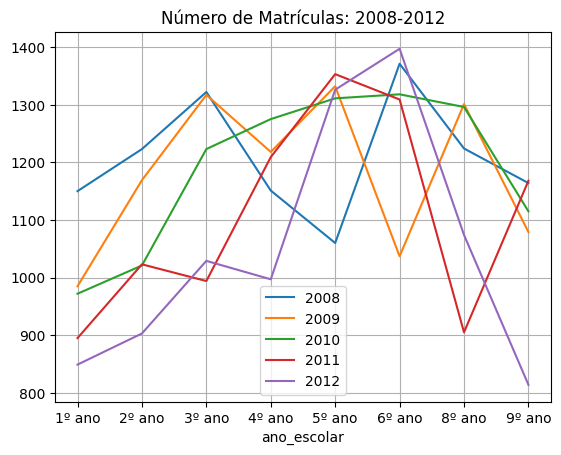

In [19]:
anos_2008_2012 = ['2008','2009','2010','2011','2012']
df_matriculas_anos.plot(x='ano_escolar', y=anos_2008_2012, title='Número de Matrículas: 2008-2012')
plt.grid(True)
plt.show()

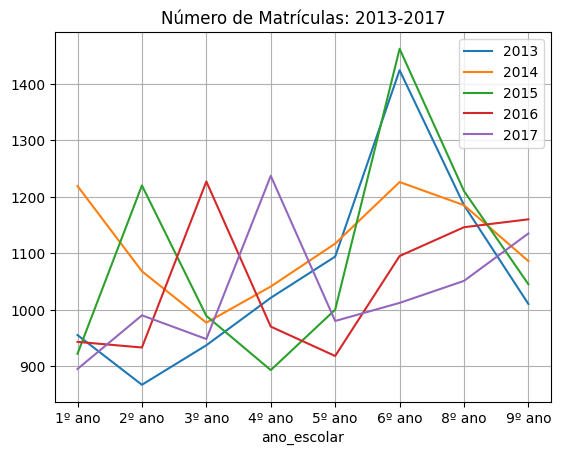

In [20]:
anos_2013_2017 = ['2013','2014','2015','2016','2017']
df_matriculas_anos.plot(x='ano_escolar', y=anos_2013_2017, title='Número de Matrículas: 2013-2017')
plt.grid(True)
plt.show()

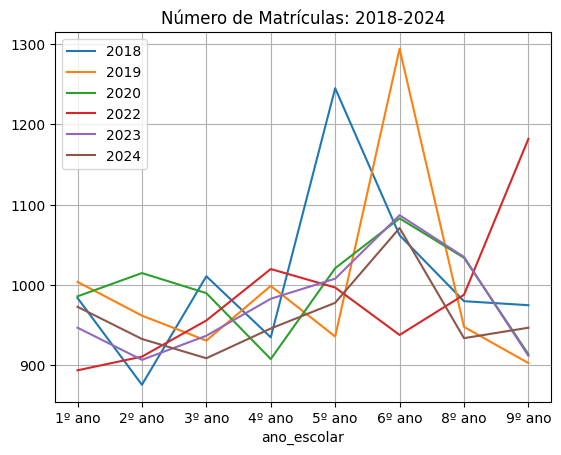

In [21]:
anos_2018_2024 = ['2018','2019','2020','2022','2023','2024']
df_matriculas_anos.plot(x='ano_escolar', y=anos_2018_2024, title='Número de Matrículas: 2018-2024')
plt.grid(True)
plt.show()

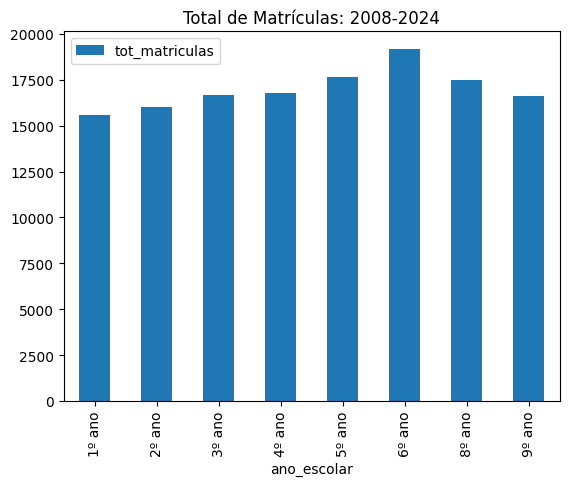

In [22]:
df_matriculas_anos.plot(x='ano_escolar', y='tot_matriculas', title='Total de Matrículas: 2008-2024', kind='bar')
plt.show()

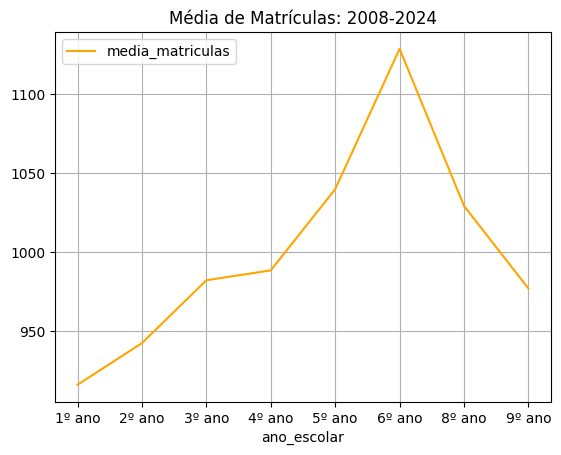

In [23]:
df_matriculas_anos.plot(x='ano_escolar', y='media_matriculas', title='Média de Matrículas: 2008-2024', color='orange')
plt.grid(True)
plt.show()

**Resultado da pesquisa e análise:**

Após a padronização e analise dos dados, foi possível observar uma queda acertuada nas matriculas escolares de 2018 em diante, principalmente nos primeiros anos escolares.

Existem diversos fatores que podem ter influenciado neste resultado, como a queda na taxa de natalidade(que também será tema de outro projeto) e a problematica acerca da evasão escolar que vem se tornando um problema crescente no nosso país.